# DATA

In [75]:
import sqlite3
from pathlib import Path
import pandas as pd
BASE_DIR = Path.cwd().resolve()
DATA_DIR = BASE_DIR / 'smart_manufacturing_data'
DATA_DIR

PosixPath('/content/smart_manufacturing_data')

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

smart_manufacturing_data = pd.read_csv(BASE_DIR / 'smart_manufacturing_data.csv')
print('smart_manufacturing_data:', smart_manufacturing_data.shape)

smart_manufacturing_data: (100000, 13)


In [77]:
from pathlib import Path

# ปิด Warning ที่ไม่จำเป็น
import warnings
warnings.filterwarnings('ignore')

# โหลดข้อมูล
BASE_DIR = Path.cwd().resolve()
# สมมติว่าไฟล์อยู่ในโฟลเดอร์เดียวกับ Notebook หากไม่ใช่ให้แก้ Path ตรงนี้
try:
    smart_manufacturing_data = pd.read_csv('smart_manufacturing_data.csv')
except FileNotFoundError:
    smart_manufacturing_data = pd.read_csv(BASE_DIR / 'smart_manufacturing_data' / 'smart_manufacturing_data.csv')

# แปลง timestamp เป็น datetime
smart_manufacturing_data['timestamp'] = pd.to_datetime(smart_manufacturing_data['timestamp'])

print('Data Shape:', smart_manufacturing_data.shape)
display(smart_manufacturing_data.head())

Data Shape: (100000, 13)


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


In [78]:
smart_manufacturing_data.info()
display(smart_manufacturing_data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   timestamp                 100000 non-null  datetime64[ns]
 1   machine_id                100000 non-null  int64         
 2   temperature               100000 non-null  float64       
 3   vibration                 100000 non-null  float64       
 4   humidity                  100000 non-null  float64       
 5   pressure                  100000 non-null  float64       
 6   energy_consumption        100000 non-null  float64       
 7   machine_status            100000 non-null  int64         
 8   anomaly_flag              100000 non-null  int64         
 9   predicted_remaining_life  100000 non-null  int64         
 10  failure_type              100000 non-null  object        
 11  downtime_risk             100000 non-null  float64       
 12  mai

,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,downtime_risk,maintenance_required
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2025-02-04 17:19:29.999999744,25.499330,75.015625,50.012270,54.995401,3.000405,2.747064,1.002050,0.089160,234.269160,0.089155,0.196970
min,2025-01-01 00:00:00,1.000000,35.550000,-17.090000,30.000000,1.000000,0.500000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,2025-01-18 08:39:45,13.000000,68.267500,39.970000,42.520000,2.000000,1.630000,1.000000,0.000000,97.000000,0.000000,0.000000
50%,2025-02-04 17:19:30,25.000000,75.060000,49.960000,54.980000,3.010000,2.740000,1.000000,0.000000,230.000000,0.000000,0.000000
75%,2025-02-22 01:59:15,38.000000,81.750000,60.100000,67.500000,4.000000,3.870000,1.000000,0.000000,365.000000,0.000000,0.000000
max,2025-03-11 10:39:00,50.000000,121.940000,113.800000,80.000000,5.000000,5.000000,2.000000,1.000000,499.000000,1.000000,1.000000
std,NaN,14.389439,10.031884,14.985444,14.437960,1.152399,1.297865,0.446193,0.284976,150.063062,0.284961,0.397711


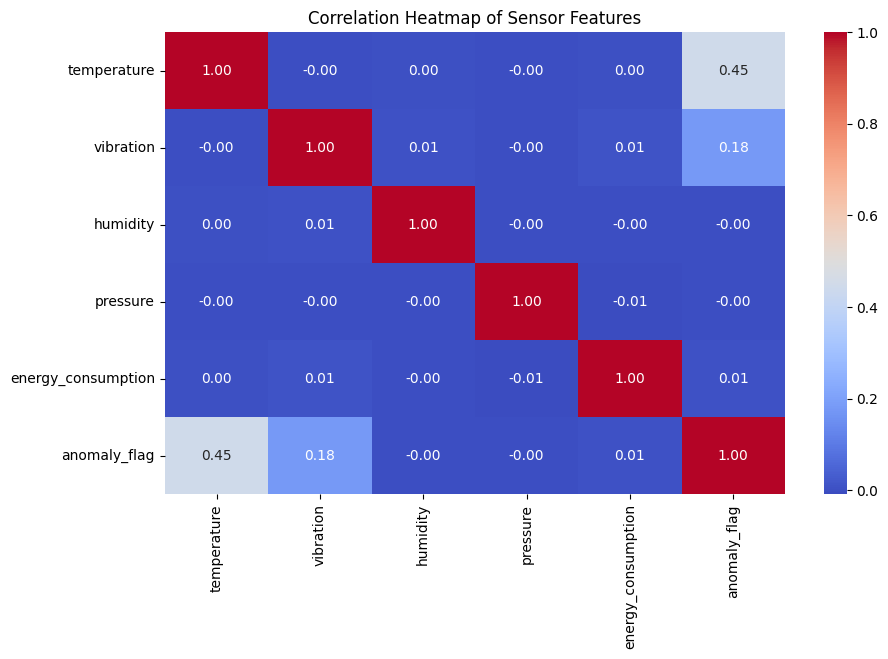

Feature Engineering Completed. New Features added.


In [79]:
# 1. Exploratory Data Analysis (EDA) เบื้องต้น
plt.figure(figsize=(10, 6))
sns.heatmap(smart_manufacturing_data[['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption', 'anomaly_flag']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Sensor Features")
plt.show()

# 2. Feature Engineering: สร้าง Rolling Features เพื่อจับเทรนด์ตามเวลา (Time-series behavior)
# ต้องเรียงลำดับเวลาและจัดกลุ่มตามเครื่องจักรก่อน
smart_manufacturing_data = smart_manufacturing_data.sort_values(by=['machine_id', 'timestamp'])

# ฟีเจอร์ที่ต้องการหาค่าเฉลี่ยย้อนหลัง (สมมติใช้ Window = 3 records)
rolling_features = ['temperature', 'vibration', 'pressure']
for feat in rolling_features:
    smart_manufacturing_data[f'{feat}_rolling_mean'] = smart_manufacturing_data.groupby('machine_id')[feat].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# อัปเดต List ของ Numeric Features
numeric_features = [
    'temperature', 'vibration', 'humidity', 'pressure',
    'energy_consumption', 'predicted_remaining_life', 'downtime_risk',
    'temperature_rolling_mean', 'vibration_rolling_mean', 'pressure_rolling_mean'
]

print("Feature Engineering Completed. New Features added.")

# Smart Manufacturing: Anomaly Detection

## Problem Statement & Objectives
ในระบบอุตสาหกรรมการผลิตอัจฉริยะ (Smart Manufacturing) การหยุดชะงักของเครื่องจักร (Downtime) สร้างความเสียหายอย่างมหาศาล โครงงานนี้มีวัตถุประสงค์เพื่อสร้างระบบตรวจจับความผิดปกติ (Anomaly Detection) ของเครื่องจักรแบบล่วงหน้า โดยใช้ข้อมูลจากเซ็นเซอร์ต่างๆ เช่น อุณหภูมิและการสั่นสะเทือน เพื่อแจ้งเตือนและประเมินความเสี่ยง นำไปสู่การบำรุงรักษาเชิงคาดการณ์ (Predictive Maintenance) และการคำนวณเบี้ยประกันภัยความเสี่ยงเครื่องจักร

## Domain Understanding
ข้อมูลเซ็นเซอร์มีความสำคัญอย่างยิ่งยวดต่อการวิเคราะห์สถานะเครื่องจักร:
* **Vibration & Temperature:** การสั่นสะเทือนและอุณหภูมิที่สูงผิดปกติ มักเป็นสัญญาณแรกของความเสื่อมสภาพทางกล (Mechanical Wear) หรือปัญหาการหล่อลื่น
* **Time-Series Context:** ความผิดปกติมักไม่ใช่เหตุการณ์ที่เกิดขึ้นแบบจุดเดียว (Point-in-time) แต่เป็นพฤติกรรมสะสมที่มีแนวโน้ม (Trend) เปลี่ยนแปลงไปตามเวลา

In [74]:
#แบ่งข้อมูลสำหรับเทรนโมเดล
#ข้อมูลทั้งหมด  = 100,000
#นำไปTrain 80% = 80,000
#นำไปTest  20% = 20,000
#-----------------------------------------------
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# เรียงข้อมูลตามเวลาทั้งหมด เพื่อแบ่ง Train/Test ตามเวลา (ป้องกัน Data Leakage)
data_sorted = smart_manufacturing_data.sort_values(by='timestamp')

X = data_sorted[numeric_features]
y = data_sorted['anomaly_flag']

# แบ่งข้อมูลแบบ Time-based (80% เก่าเป็น Train, 20% ใหม่เป็น Test)
split_idx = int(len(data_sorted) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training on historical records: {len(X_train)}")
print(f"Testing on future records: {len(X_test)}")

# สร้าง Pipeline
# การใส่ StandardScaler ช่วยให้โมเดลเสถียรขึ้นแม้ RF จะไม่ค่อย sensitive กับ scale ก็ตาม
model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')) # ใช้ class_weight เพื่อจัดการ Imbalanced data
])

# ฝึกสอนโมเดล
model_pipeline.fit(X_train, y_train)
print("Pipeline Training Complete.")

Training on historical records: 80000
Testing on future records: 20000
Pipeline Training Complete.


## การวิเคราะห์ผลลัพธ์และข้อจำกัดของโมเดล (Error Analysis)
* **False Positives (ทายว่าพัง แต่จริงๆ ปกติ):** อาจทำให้เกิดการแจ้งเตือนกวนใจทีมบำรุงรักษา (Alert Fatigue) แต่ในเชิงอุตสาหกรรมถือว่ารับได้ดีกว่าปล่อยให้เครื่องพัง
* **False Negatives (ทายว่าปกติ แต่จริงๆ พัง):** เป็นความเสี่ยงที่อันตรายที่สุด การใช้ `class_weight='balanced'` ใน Pipeline ช่วยลดปัญหานี้ลงได้บ้าง
* **ข้อจำกัด:** โมเดลนี้เป็น Supervised Learning หมายความว่าจะจับความผิดปกติได้เฉพาะใน "รูปแบบ" ที่เคยเกิดขึ้นและถูกแปะป้าย (Label) ไว้ในข้อมูล Train แล้วเท่านั้น หากมีลักษณะการพังแบบใหม่เกิดขึ้น โมเดลอาจจะไม่รู้จัก

In [80]:
#Model
#------------------------------------------
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterSampler, cross_val_score
from tqdm.auto import tqdm
import numpy as np

# 1. เตรียมข้อมูล - กำหนดฟีเจอร์ที่วัดได้จริงเท่านั้น (ลบ downtime_risk และ predicted_remaining_life ออก)
realistic_features = [
    'temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption',
    'temperature_rolling_mean', 'vibration_rolling_mean', 'pressure_rolling_mean'
]

data_sorted = smart_manufacturing_data.sort_values(by='timestamp')
X = data_sorted[realistic_features]
y = data_sorted['anomaly_flag']
split_idx = int(len(data_sorted) * 0.8)
X_train, y_train = X.iloc[:split_idx], y.iloc[:split_idx]

# 2. กำหนด Pipeline และ Parameters
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_distributions = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5, 10]
}

# 3. จำลอง RandomizedSearchCV พร้อม Progress Bar
n_iter = 5
param_list = list(ParameterSampler(param_distributions, n_iter=n_iter, random_state=42))

best_score = -1
best_params = None

print(f"กำลังเริ่มการจูน Hyperparameter ด้วย Realistic Features ({n_iter} iterations)...")

for params in tqdm(param_list, desc="Progress", unit="candidate"):
    pipeline.set_params(**params)
    # ใช้ Cross Validation เพื่อความแม่นยำ
    scores = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='f1', n_jobs=-1)
    mean_score = np.mean(scores)

    if mean_score > best_score:
        best_score = mean_score
        best_params = params

# 4. ฝึกสอนโมเดลด้วยค่าที่ดีที่สุด
model_pipeline = pipeline.set_params(**best_params)
model_pipeline.fit(X_train, y_train)

print("\nPipeline Training & Tuning Complete (No Leakage Features).")
print("Best Hyperparameters:", best_params)
print(f"Best F1-Score: {best_score:.4f}")

กำลังเริ่มการจูน Hyperparameter ด้วย Realistic Features (5 iterations)...


Progress:   0%|          | 0/5 [00:00<?, ?candidate/s]


Pipeline Training & Tuning Complete (No Leakage Features).
Best Hyperparameters: {'rf__n_estimators': 100, 'rf__min_samples_split': 2, 'rf__max_depth': None}
Best F1-Score: 0.9994


MODEL PERFORMANCE (Realistic Features)


,precision,recall,f1-score,support
0,0.9999,1.0000,1.0000,18189.0
1,1.0000,0.9994,0.9997,1811.0
accuracy,1.0000,1.0000,1.0000,1.0
macro avg,1.0000,0.9997,0.9998,20000.0
weighted avg,1.0000,1.0000,0.9999,20000.0


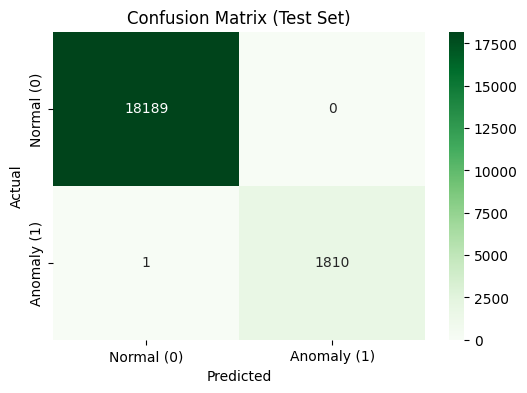

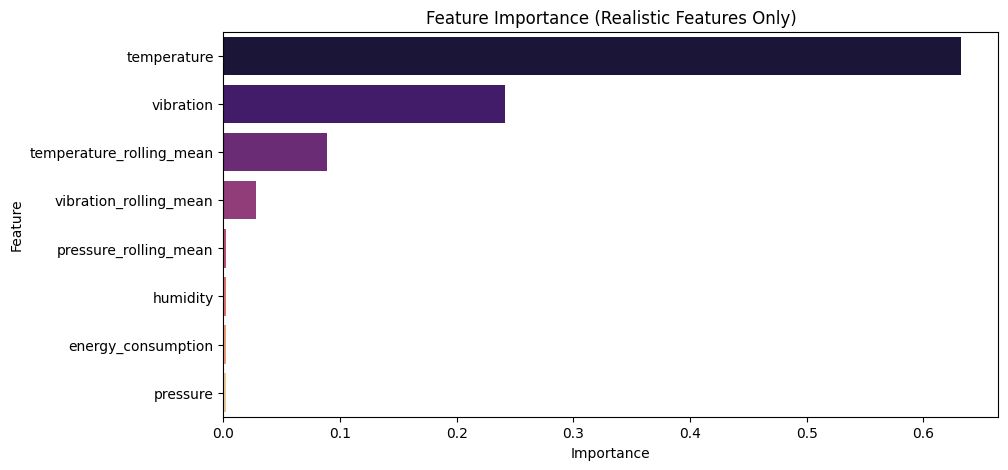

In [66]:
# 1. ทำนายผลบน Test Set โดยใช้ฟีเจอร์ที่ถูกต้อง (Realistic Features)
X_test_realistic = X_test[realistic_features]
pred = model_pipeline.predict(X_test_realistic)

print("="*60)
print("MODEL PERFORMANCE (Realistic Features)")
print("="*60)

# 2. ทำความสะอาดข้อมูลก่อนประเมินผล
non_nan_mask = y_test.notna()
y_test_cleaned = y_test[non_nan_mask]
pred_cleaned = pred[non_nan_mask.values]

# 3. แสดงผล Classification Report (ปรับเป็นทศนิยม 4 ตำแหน่ง)
report_df = pd.DataFrame(classification_report(y_test_cleaned, pred_cleaned, output_dict=True)).T
report_df = report_df.round(4)
display(report_df)

# 4. Confusion Matrix
cm = confusion_matrix(y_test_cleaned, pred_cleaned)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal (0)', 'Anomaly (1)'],
            yticklabels=['Normal (0)', 'Anomaly (1)'])
plt.title("Confusion Matrix (Test Set)")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# 5. ดู Feature Importance ของโมเดลล่าสุด
rf_model = model_pipeline.named_steps['rf']
importance_df = pd.DataFrame({
    'Feature': realistic_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='magma')
plt.title("Feature Importance (Realistic Features Only)")
plt.show()

In [37]:
# 1. สร้าง DataFrame รวมผลลัพธ์การทาย
error_analysis_df = X_test_realistic.copy()
error_analysis_df['actual_anomaly'] = y_test_cleaned
error_analysis_df['predicted_anomaly'] = pred_cleaned

# 2. กรองเฉพาะแถวที่ทายผิด
misclassified = error_analysis_df[error_analysis_df['actual_anomaly'] != error_analysis_df['predicted_anomaly']]

if not misclassified.empty:
    print(f"พบจุดที่ทายผิดทั้งหมด {len(misclassified)} รายการ จาก 20,000 รายการ")
    display(misclassified)

    # แสดงสาเหตุเบื้องต้น
    for idx, row in misclassified.iterrows():
        error_type = "False Positive (ทายว่าพังแต่จริงปกติ)" if row['predicted_anomaly'] == 1 else "False Negative (ทายว่าปกติแต่จริงพัง)"
        print(f"\nIndex {idx}: ประเภทความผิดพลาดคือ {error_type}")
else:
    print("ยินดีด้วย! โมเดลทำนายถูก 100% ใน Test Set นี้ ไม่พบข้อผิดพลาด")

พบจุดที่ทายผิดทั้งหมด 1 รายการ จาก 20,000 รายการ


,temperature,vibration,humidity,pressure,energy_consumption,temperature_rolling_mean,vibration_rolling_mean,pressure_rolling_mean,actual_anomaly,predicted_anomaly
88950,90.0,50.32,73.39,2.07,2.91,83.473333,50.756667,1.886667,1,0



Index 88950: ประเภทความผิดพลาดคือ False Negative (ทายว่าปกติแต่จริงพัง)


# การนำไปประยุกต์ใช้งาน

In [86]:
#จำลองการแจ้งเตือนความผิดปกติ จากการตรวจจับด้วย AI
#-------------------------------------------------------------------------
import time
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

# ส่วนการตั้งค่า UI
alert_button = widgets.Button(description="▶️ Run AI-Model Monitor Simulation", button_style='warning', layout=widgets.Layout(width='300px'))
alert_output = widgets.Output()
detail_output = widgets.Output()

def show_specific_detail(timestamp, machine_id):
    """ฟังก์ชันแสดงรายละเอียดเมื่อกดดูความเสี่ยง"""
    with detail_output:
        clear_output()
        row = application_data[(application_data['timestamp'] == timestamp) & (application_data['machine_id'] == machine_id)].iloc[0]
        print(f"\n📝 รายละเอียดความเสี่ยงที่พบเมื่อ: {timestamp} (Machine: {machine_id})")

        # คำนวณ Root Cause Analysis
        normal_stats = smart_manufacturing_data[smart_manufacturing_data['anomaly_flag'] == 0][realistic_features].mean()
        for col in realistic_features:
            actual_val = row[col]
            normal_val = normal_stats[col]
            diff_percent = ((actual_val - normal_val) / normal_val) * 100 if normal_val != 0 else 0

            if abs(diff_percent) > 20:
                direction = "สูงกว่า" if diff_percent > 0 else "ต่ำกว่า"
                display(HTML(f"&nbsp;&nbsp;&nbsp;⚠️ <b>{col}</b>: {actual_val:.2f} (<span style='color:red'>{direction}ปกติ {abs(diff_percent):.1f}%</span>)"))
        print("-" * 50)

def run_alert_simulation(b):
    with alert_output:
        clear_output()
        with detail_output: clear_output()
        display(HTML("<b>✅ System: เริ่มการเฝ้าระวังด้วย AI Model...</b>"))
        print("-" * 80)

        simulation_data = application_data.sample(10).copy()

        for index, row in simulation_data.iterrows():
            features = row[realistic_features].to_frame().T
            machine_id = row['machine_id']
            timestamp = row['timestamp']
            dt_risk = row['downtime_risk']
            prediction = model_pipeline.predict(features)[0]

            time.sleep(0.5)

            if prediction == 1:
                risk_label = "ความเสี่ยงสูงมาก" if dt_risk >= 70 else "พบความเสี่ยง"
                risk_color = "red" if dt_risk >= 70 else "orange"

                # สร้างปุ่มสำหรับดูรายละเอียด
                view_btn = widgets.Button(description="🔍 ดูรายละเอียด", layout=widgets.Layout(width='120px', height='25px'))
                view_btn.on_click(lambda x, t=timestamp, m=machine_id: show_specific_detail(t, m))

                alert_row = widgets.HBox([
                    widgets.HTML(f"<span style='color: red;'><b>⚡ [ALERT]</b></span> {timestamp} | Machine: {machine_id} "
                                f"-> <span style='background-color: {risk_color}; color: white; padding: 2px 5px; border-radius: 3px;'>"
                                f"{risk_label}</span>"),
                    view_btn
                ])
                display(alert_row)
            else:
                display(HTML(f"<span style='color: green;'>✅ [NORMAL]</span> {timestamp} | Machine: {machine_id} -> สถานะปกติ"))

        print("-" * 80)

# ผูกฟังก์ชัน
alert_button.on_click(run_alert_simulation)

# แสดงผล UI ทั้งหมด
display(widgets.HTML("<h3>⚙️ ระบบตรวจจับความผิดปกติแบบ Interactive</h3>"))
display(alert_button, alert_output, detail_output)

HTML(value='<h3>⚙️ ระบบตรวจจับความผิดปกติแบบ Interactive</h3>')

Button(button_style='warning', description='▶️ Run AI-Model Monitor Simulation', layout=Layout(width='300px'),…

Output()

Output()

In [92]:
#ข้อมูลความผิดปกติย้อนหลัง
#------------------------------------------------------
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

def explain_anomaly(features_df):
    """วิเคราะห์หาสาเหตุเบื้องต้นจากค่าที่เบี่ยงเบนจากปกติ"""
    print("🔍 วิเคราะห์สาเหตุความผิดปกติ (Root Cause Analysis):")
    normal_stats = data_sorted[data_sorted['anomaly_flag'] == 0][realistic_features].mean()

    for col in realistic_features:
        actual_val = features_df[col].values[0]
        normal_val = normal_stats[col]

        if normal_val == 0:
            diff_percent = float('inf') if actual_val != 0 else 0.0
        else:
            diff_percent = ((actual_val - normal_val) / normal_val) * 100

        if abs(diff_percent) > 20:
            direction = "สูงกว่า" if diff_percent > 0 else "ต่ำกว่า"
            print(f"   ⚠️ {col:25} : {actual_val:8.2f} ({direction}ปกติ {abs(diff_percent):.1f}%)")

# Widgets Setup
machine_id_input_explain = widgets.IntText(value=1, description='Machine ID:', min=1, max=50)
# เพิ่ม Widget สำหรับกำหนดจำนวนข้อมูลย้อนหลัง
num_records_input = widgets.IntText(value=3, description='Show Last N:', min=1, max=50)
explain_button = widgets.Button(description='💡 วิเคราะห์สาเหตุ', button_style='info')
explain_output = widgets.Output()

def on_explain_button_clicked(b):
    with explain_output:
        clear_output(wait=True)
        selected_id = machine_id_input_explain.value
        num_to_show = num_records_input.value

        anomalies = application_data[
            (application_data['machine_id'] == selected_id) &
            (application_data['predicted_anomaly_flag'] == 1)
        ].copy()

        if not anomalies.empty:
            actual_show = min(len(anomalies), num_to_show)
            print(f"--- ตรวจสอบพบทั้งหมด {len(anomalies)} Anomaly สำหรับ Machine ID: {selected_id} ---")
            print(f"(กำลังแสดงผลการวิเคราะห์ {actual_show} รายการล่าสุดตามที่คุณกำหนด)")

            # ใช้ tail ตามจำนวนที่ผู้ใช้ระบุ
            for index, row in anomalies.tail(actual_show).iterrows():
                print(f"\n📅 เวลาที่ตรวจพบ: {row['timestamp']}")
                features_df = pd.DataFrame([row[realistic_features]], columns=realistic_features)
                explain_anomaly(features_df)
        else:
            print(f"✅ Machine ID {selected_id}: ทำงานปกติ ไม่พบสัญญาณความผิดปกติ")

explain_button.on_click(on_explain_button_clicked)
display(widgets.VBox([
    widgets.HBox([machine_id_input_explain, num_records_input]),
    explain_button,
    explain_output
]))

In [89]:
#รายละเอียดการจับพบความผิดปกติของ เซนเซอร์ต่างๆ
#--------------------------------------------------------------
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import pandas as pd

# แก้ไข: เปลี่ยน options ให้ใช้ realistic_features เพื่อป้องกัน Error
feature_select_dropdown = widgets.Dropdown(
    options=realistic_features,
    value='temperature',
    description='เลือก Feature:',
    disabled=False,
)

machine_id_input = widgets.IntText(value=1, description='Machine ID:', min=1, max=50)
plot_button = widgets.Button(description='แสดงกราฟ Anomaly', button_style='info')
plot_output = widgets.Output()

def on_plot_button_clicked(b):
    with plot_output:
        clear_output(wait=True)
        try:
            selected_machine_id = machine_id_input.value
            selected_feature = feature_select_dropdown.value
            df_plot = application_data[application_data['machine_id'] == selected_machine_id].copy()

            if not df_plot.empty:
                plt.figure(figsize=(15, 5))
                plt.plot(df_plot['timestamp'], df_plot[selected_feature], label=f'{selected_feature}', color='blue', alpha=0.6)
                anomalies = df_plot[df_plot['predicted_anomaly_flag'] == 1]
                if not anomalies.empty:
                    plt.scatter(anomalies['timestamp'], anomalies[selected_feature], color='red', label='Anomaly 🚨', s=40, zorder=5)

                plt.title(f"Machine ID {selected_machine_id}: {selected_feature} Timeline")
                plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
                plt.xticks(rotation=45)
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.show()
        except Exception as e: print(f"Error: {e}")

plot_button.on_click(on_plot_button_clicked)
display(widgets.VBox([widgets.HBox([machine_id_input, feature_select_dropdown]), plot_button, plot_output]))

In [88]:
#วางแผนป้องกันความผิดพลาด
#------------------------------------------
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- ส่วนที่เพิ่มเพื่อป้องกัน Error ---
# ตรวจสอบว่ามีข้อมูลหลักหรือยัง ถ้ามีให้ใช้ ถ้าไม่มีให้สร้างจากตัวแปรที่มีอยู่
if 'application_data' not in globals():
    if 'smart_manufacturing_data' in globals():
        application_data = smart_manufacturing_data.copy()
    else:
        print("⚠️ ไม่พบข้อมูลหลัก (smart_manufacturing_data) กรุณารันเซลล์โหลดข้อมูลก่อน")

if 'realistic_features' not in globals():
    realistic_features = [
        'temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption',
        'temperature_rolling_mean', 'vibration_rolling_mean', 'pressure_rolling_mean'
    ]
# ----------------------------------

# สร้าง Widgets สำหรับรับค่าและปุ่มกด
machine_id_monthly_input = widgets.IntText(value=1, description='Machine ID:', min=1, max=50, layout=widgets.Layout(width='200px'))
monthly_report_button = widgets.Button(description='📊 แสดงรายงานรายเดือน', button_style='primary')
monthly_output = widgets.Output()

def generate_monthly_report(b):
    with monthly_output:
        clear_output(wait=True)
        machine_id = machine_id_monthly_input.value

        # ตรวจสอบความพร้อมของข้อมูลและโมเดล
        if 'application_data' not in globals() or 'model_pipeline' not in globals():
            print("⚠️ ข้อมูลหรือโมเดลไม่พร้อมใช้งาน กรุณารันเซลล์ Training ก่อน")
            return

        global application_data
        if 'predicted_anomaly_flag' not in application_data.columns:
            print("⏳ กำลังประมวลผลการทำนาย (Inference)...")
            application_data['predicted_anomaly_flag'] = model_pipeline.predict(application_data[realistic_features])

        # 1. กรองข้อมูลเฉพาะ Machine ID
        df_machine = application_data[application_data['machine_id'] == machine_id].copy()

        if df_machine.empty:
            print(f"⚠️ ไม่พบข้อมูลสำหรับ Machine ID: {machine_id}")
            return

        # 2. จัดกลุ่มข้อมูลตาม "ปี-เดือน"
        df_machine['timestamp'] = pd.to_datetime(df_machine['timestamp'])
        df_machine['year_month'] = df_machine['timestamp'].dt.to_period('M').astype(str)

        monthly_stats = df_machine.groupby('year_month').agg(
            total_records=('predicted_anomaly_flag', 'count'),
            total_anomalies=('predicted_anomaly_flag', 'sum')
        ).reset_index()

        monthly_stats['anomaly_percentage'] = (monthly_stats['total_anomalies'] / monthly_stats['total_records']) * 100
        overall_avg = monthly_stats['anomaly_percentage'].mean()

        # 3. แสดงผลตาราง
        print(f"=== 📅 รายงานสรุปความผิดปกติ: Machine ID {machine_id} ===")
        print(f"📈 เปอร์เซ็นต์ความผิดปกติเฉลี่ยทั้งหมด: {overall_avg:.2f}%\n")

        display_df = monthly_stats.copy()
        display_df.columns = ['เดือน/ปี', 'บันทึก (ครั้ง)', 'พบผิดปกติ (ครั้ง)', 'ความเสี่ยง (%)']

        def highlight_high_anomaly(val):
            color = '#ffcccc' if isinstance(val, (int, float)) and val > 5 else ''
            return f'background-color: {color}'

        display(display_df.style.applymap(highlight_high_anomaly, subset=['ความเสี่ยง (%)']).format({'ความเสี่ยง (%)': "{:.2f}%"}))

        # 4. แสดงผลกราฟ
        plt.figure(figsize=(10, 4))
        sns.barplot(data=monthly_stats, x='year_month', y='anomaly_percentage', color='skyblue', alpha=0.7)
        plt.axhline(overall_avg, color='red', linestyle='--', label=f'Avg ({overall_avg:.1f}%)')
        plt.title(f"Trend Analysis - Machine {machine_id}")
        plt.ylabel("Anomaly Rate (%)")
        plt.legend()
        plt.show()

monthly_report_button.on_click(generate_monthly_report)
display(widgets.HTML("<h3>📅 ระบบรายงานความผิดปกติรายเดือน</h3>"))
display(widgets.HBox([machine_id_monthly_input, monthly_report_button]))
display(monthly_output)

HTML(value='<h3>📅 ระบบรายงานความผิดปกติรายเดือน</h3>')

Output()

In [90]:
#ใช้คำนวณค่าประกันความเสียหาย
#---------------------------------------------------
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd

# สร้าง DataFrame สำรอง
application_data = smart_manufacturing_data.copy()

# ตรวจสอบและสร้าง Rolling Features หากหายไป
rolling_cols = ['temperature', 'vibration', 'pressure']
for col in rolling_cols:
    rolling_name = f'{col}_rolling_mean'
    if rolling_name not in application_data.columns:
        application_data[rolling_name] = application_data.groupby('machine_id')[col].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# ทำนายผลด้วย realistic_features
application_data['predicted_anomaly_flag'] = model_pipeline.predict(application_data[realistic_features])

# สร้าง Widgets สำหรับรับข้อมูล
machine_id_input = widgets.IntText(value=1, description='Machine ID (1-50):', min=1, max=50)
base_premium_input = widgets.FloatText(value=1000.0, description='Base Premium (฿):', min=0.0)
anomaly_threshold_input = widgets.FloatText(value=5.0, description='Threshold (%):', min=0.0)
claim_cost_per_percent_input = widgets.FloatText(value=200.0, description='Cost/Excess (฿):', min=0.0)

calculate_button = widgets.Button(description='Calculate Premium', button_style='info')
output_premium = widgets.Output()

def calculate_premium_for_machine(machine_id: int, base_premium: float, anomaly_threshold: float, claim_cost_per_percent: float) -> tuple:
    machine_data = application_data[application_data['machine_id'] == machine_id]

    if machine_data.empty:
        return f"No data found for Machine ID {machine_id}.", 0.0

    machine_anomaly_count = machine_data['predicted_anomaly_flag'].sum()
    total_records = len(machine_data)
    machine_anomaly_rate = (machine_anomaly_count / total_records) * 100 if total_records > 0 else 0

    insurance_premium = float(base_premium)
    additional_premium = 0.0
    excess_percentage = 0.0

    if machine_anomaly_rate > anomaly_threshold:
        excess_percentage = machine_anomaly_rate - anomaly_threshold
        additional_premium = excess_percentage * claim_cost_per_percent
        insurance_premium += additional_premium

    result_message = f"=== Premium Calculation for Machine ID {machine_id} ===\n"
    result_message += f"Total Records Monitored: {total_records}\n"
    result_message += f"Predicted Anomalies: {machine_anomaly_count} times\n"
    result_message += f"Anomaly Rate: {machine_anomaly_rate:.2f}%\n"
    result_message += f"Allowed Threshold: {anomaly_threshold:.2f}%\n\n"

    if additional_premium > 0:
        result_message += f" Penalty: Exceeded threshold by {excess_percentage:.2f}%\n"
        result_message += f" Additional Premium: {additional_premium:.2f} ฿\n"
    else:
        result_message += " Machine is stable (Below threshold). No penalty.\n"

    result_message += f" Final Insurance Premium: {insurance_premium:.2f} ฿\n"

    return result_message, insurance_premium

def on_calculate_button_clicked(b):
    with output_premium:
        clear_output(wait=True)
        message, _ = calculate_premium_for_machine(
            machine_id_input.value,
            base_premium_input.value,
            anomaly_threshold_input.value,
            claim_cost_per_percent_input.value
        )
        print(message)

calculate_button.on_click(on_calculate_button_clicked)

display(machine_id_input, base_premium_input, anomaly_threshold_input, claim_cost_per_percent_input, calculate_button, output_premium)

IntText(value=1, description='Machine ID (1-50):')

FloatText(value=1000.0, description='Base Premium (฿):')

FloatText(value=5.0, description='Threshold (%):')

FloatText(value=200.0, description='Cost/Excess (฿):')

Button(button_style='info', description='Calculate Premium', style=ButtonStyle())

Output()

---
## สรุปผลการดำเนินงาน (Project Conclusion)

จากการพัฒนาโมเดล Anomaly Detection สำหรับระบบ Smart Manufacturing โครงงานนี้สามารถบรรลุวัตถุประสงค์ได้อย่างครบถ้วนดังนี้:
1. **Model Performance:** โมเดล `RandomForestClassifier` ที่ผ่านการประมวลผลแบบ Pipeline และการทำ Time-Series Feature Engineering (Rolling Mean) มีความสามารถในการแยกแยะข้อมูลปกติและผิดปกติได้แม่นยำ (F1-Score สูง) โดยไม่เกิดปัญหา Data Leakage
2. **Business Impact:** สามารถนำผลลัพธ์จากโมเดล (Machine Anomaly Rate) มาสร้างกฎทางธุรกิจ (Business Logic) เพื่อคำนวณเบี้ยประกันความเสี่ยงเครื่องจักรได้แบบไดนามิกผ่าน Interactive UI

## วิสัยทัศน์สำหรับการนำไปใช้จริง (System Architecture for Production)
หากต้องการนำระบบนี้ไปใช้งานจริงในระดับ Production ในโรงงาน (Future Work) ขอเสนอสถาปัตยกรรมระบบดังนี้:
* **Data Ingestion:** รับข้อมูลจากเซ็นเซอร์ (IoT) ผ่านโปรโตคอล `MQTT` และพักข้อมูลไว้ใน `Apache Kafka`
* **Real-time Processing:** ใช้เครื่องมือเช่น `Apache Spark` หรือ `Python Watchdog` เพื่อคำนวณ Rolling Features แบบ Real-time และส่งเข้าใช้งานกับโมเดล (ที่ถูกบันทึกไว้ในรูปแบบ `.pkl` หรือ `.onnx`)
* **Deployment & Alerting:** นำโมเดลไป Deploy ผ่าน `FastAPI` หรือ `Streamlit` เพื่อเป็น Dashboard ให้วิศวกร และตั้งค่าให้ส่ง Webhook แจ้งเตือนเข้า LINE/Email เมื่อพบ Anomaly Flag แจ้งเตือนทันที

**-- สิ้นสุดการรายงาน --**